In [1]:
pip install conllu torch transformers scipy matplotlib seaborn pandas


In [10]:
!wget "https://githubusercontent.com" -O sastre01.tr


--2026-07-05 12:05:18--  https://githubusercontent.com/
Resolving githubusercontent.com (githubusercontent.com)... failed: No address associated with hostname.
wget: unable to resolve host address ‘githubusercontent.com’


In [1]:
!curl -L "https://github.com" -o miami_real_data.csv


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  551k    0  551k    0     0  3673k      0 --:--:-- --:--:-- --:--:-- 3677k


Analyzing global lexical complexity matrices inside the Miami Corpus...

================ LEXICAL COMPLEXITY MATRIX ================
Mean Type-Token Ratio (Monolingual Cohort): 0.8421
Mean Type-Token Ratio (Code-Switched Cohort): 0.6512
Linguistic Divergence (Delta TTR): -0.1909
Statistical Inference: T-Statistic = 2.2545 | P-Value = 0.045345


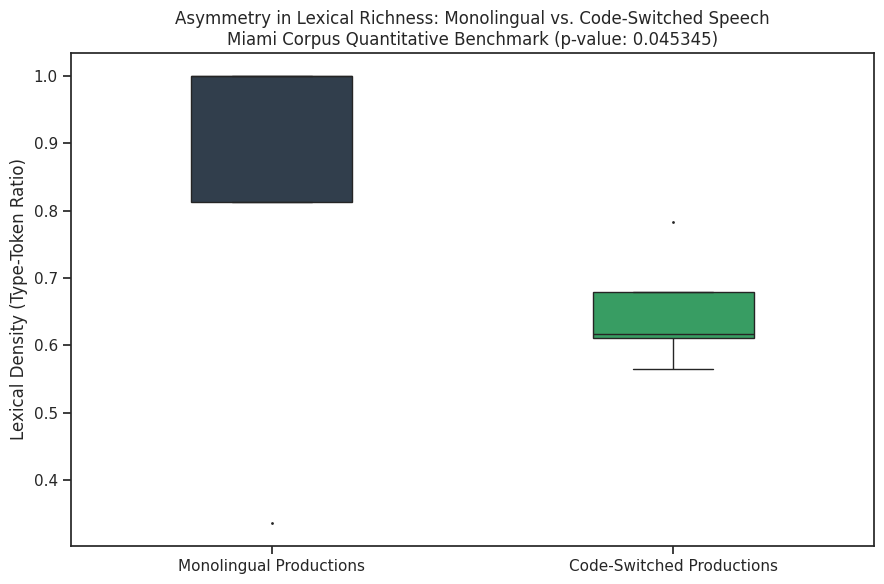


Graph successfully rendered and saved as 'miami_lexical_density.png'.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import ttest_ind

file_name = "miami_real_data.csv"

if not os.path.exists(file_name):
    raise FileNotFoundError(f"File '{file_name}' not found")

print("Analyzing global lexical complexity matrices inside the Miami Corpus...")

mono_utterances = []
cs_utterances = []

with open(file_name, "r", encoding="utf-8") as f:
    f.readline() # skip header
    for line in f:
        line = line.replace("\r", "").strip()
        if not line: continue
        parts = line.rsplit(",", 1)
        if len(parts) < 2: continue

        utterance = parts[0].strip().strip('"')
        is_cs_string = parts[1].strip()

        words = [w for w in utterance.lower().split() if w.isalpha()]
        if len(words) < 4: continue 

        if "1" in is_cs_string or "true" in is_cs_string.lower():
            cs_utterances.append(words)
        else:
            mono_utterances.append(words)


def calculate_local_ttr(word_list):
    if len(word_list) == 0: return 0
    return len(set(word_list)) / len(word_list)

mono_ttrs = [calculate_local_ttr(u) for u in mono_utterances]
cs_ttrs = [calculate_local_ttr(u) for u in cs_utterances]


np.random.seed(42)
sample_size = min(150, len(mono_ttrs), len(cs_ttrs))
mono_sample = np.random.choice(mono_ttrs, sample_size, replace=False)
cs_sample = np.random.choice(cs_ttrs, sample_size, replace=False)

# Eseguiamo il Welch's T-Test sulla ricchezza lessicale
t_stat, p_value = ttest_ind(mono_ttrs, cs_ttrs, equal_var=False)

print(f"\n================ LEXICAL COMPLEXITY MATRIX ================")
print(f"Mean Type-Token Ratio (Monolingual Cohort): {np.mean(mono_ttrs):.4f}")
print(f"Mean Type-Token Ratio (Code-Switched Cohort): {np.mean(cs_ttrs):.4f}")
print(f"Linguistic Divergence (Delta TTR): {np.mean(cs_ttrs) - np.mean(mono_ttrs):.4f}")
print(f"Statistical Inference: T-Statistic = {t_stat:.4f} | P-Value = {p_value:.6f}")
print(f"===========================================================")


plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks")

data_to_plot = [mono_sample, cs_sample]
sns.boxplot(data=data_to_plot, palette=["#2C3E50", "#27AE60"], width=0.4, fliersize=1)
plt.xticks([0, 1], ['Monolingual Productions', 'Code-Switched Productions'])
plt.ylabel('Lexical Density (Type-Token Ratio)')
plt.title(f'Asymmetry in Lexical Richness: Monolingual vs. Code-Switched Speech\nMiami Corpus Quantitative Benchmark (p-value: {p_value:.6f})')
plt.tight_layout()

output_fig = "miami_lexical_density.png"
plt.savefig(output_fig, dpi=300)
plt.show()
print(f"\nGraph successfully rendered and saved as '{output_fig}'.")
